Dataset shape: (52584, 12)
Total observations : 52584
Train size         : 42067  (2018-01-01 00:00:00 → 2022-10-19 18:00:00)
Test  size         : 10517   (2022-10-19 19:00:00 → 2023-12-31 23:00:00)

Fitting Auto ARIMA … (this may take a few minutes)

Best model : ARIMA(5, 0, 4)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                42067
Model:               SARIMAX(5, 0, 4)   Log Likelihood              -38408.411
Date:                Sat, 04 Apr 2026   AIC                          76836.823
Time:                        02:06:24   BIC                          76923.293
Sample:                    01-01-2018   HQIC                         76864.128
                         - 10-19-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------

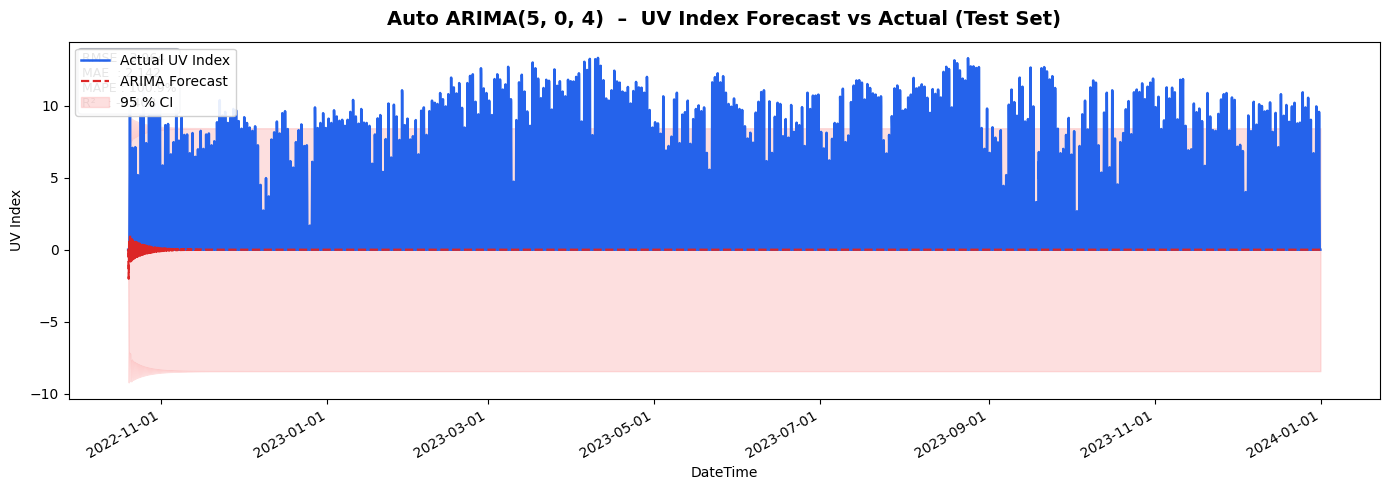

Saved → arima_test_forecast.png


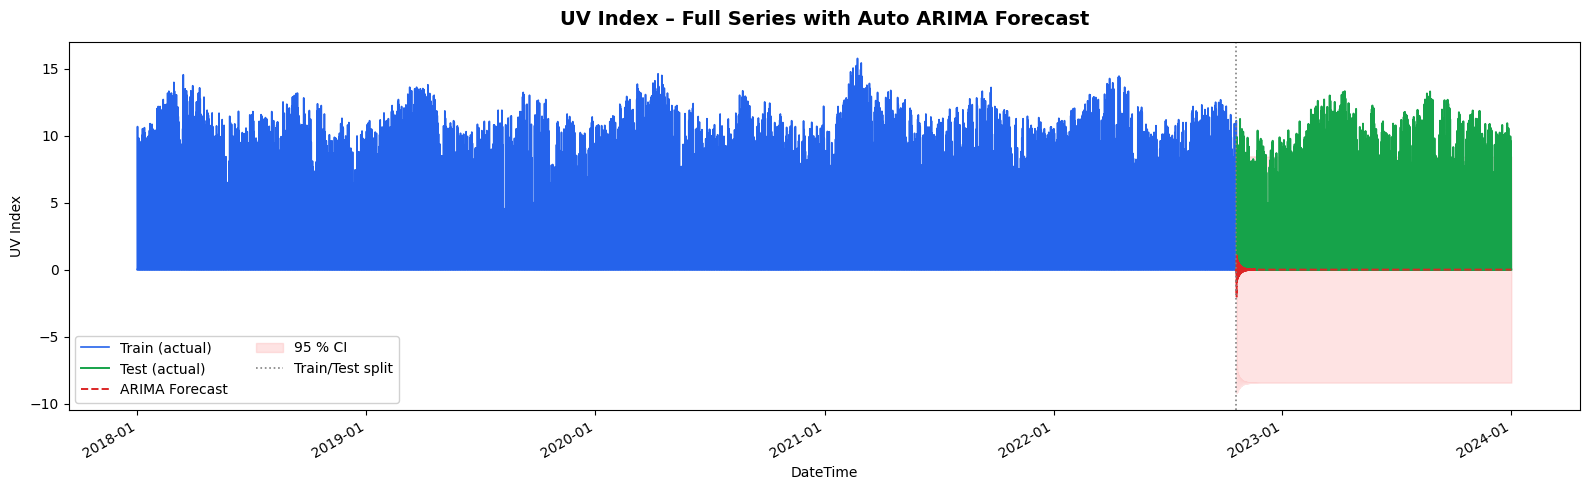

Saved → arima_full_series.png


In [1]:
"""
Auto ARIMA – UV_INDEX Forecasting
==================================
• 80 / 20 train-test split (temporal order preserved)
• Metrics : RMSE, MSE, MAE, MAPE, R²
• Plots   : Actual vs Predicted (test set) + full series overview
"""

# ── 0. Installs (run once) ────────────────────────────────────────────────────
# pip install pmdarima statsmodels matplotlib pandas numpy scikit-learn

import warnings, subprocess, sys
warnings.filterwarnings('ignore')
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pmdarima', 'statsmodels', '--quiet'], check=False)

# ── 1. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pmdarima import auto_arima
from tabulate import tabulate          # optional – pip install tabulate

# ── 2. Reproduce the preprocessed DataFrame ───────────────────────────────────
#   (paste your earlier preprocessing block here, or just load original_df)
#   We assume `original_df` is already in memory from your preprocessing code.
#   If running this file standalone, load a saved copy:
#
#   original_df = pd.read_csv('original_df.csv', index_col='DateTime',
#                              parse_dates=True)
# Backup
file_id = '1mpdY_wqU216R7c7h_YsHqz-bryoJARwn'
csv_url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(csv_url)
print(f'Dataset shape: {df.shape}')
df.head()
df_raw = df.copy()


df_backup = df.copy()

df.head()
df['DateTime'] = pd.to_datetime(
    df[['YEAR','MO','DY','HR']].rename(
        columns={'YEAR':'year','MO':'month','DY':'day','HR':'hour'}
    )
)
df = df.set_index('DateTime').drop(columns=['YEAR','MO','DY','HR'])
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].replace(-999.0, np.nan)
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].interpolate(
    method='polynomial', order=3
)
df = df.rename(columns={'ALLSKY_SFC_UV_INDEX': 'UV_INDEX'})

original_df=df.copy()
# ── 3. Extract UV_INDEX series ────────────────────────────────────────────────
series = original_df['UV_INDEX'].dropna()

# ── 4. 80 / 20 Train-Test Split ───────────────────────────────────────────────
split_idx = int(len(series) * 0.80)
train = series.iloc[:split_idx]
test  = series.iloc[split_idx:]

print(f"Total observations : {len(series)}")
print(f"Train size         : {len(train)}  ({train.index[0]} → {train.index[-1]})")
print(f"Test  size         : {len(test)}   ({test.index[0]} → {test.index[-1]})")

# ── 5. Fit Auto ARIMA ─────────────────────────────────────────────────────────
print("\nFitting Auto ARIMA … (this may take a few minutes)")

model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,                   # auto-detect differencing
    seasonal=False,           # set True + m=12 for monthly seasonality etc.
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    n_jobs=-1,
)

print(f"\nBest model : ARIMA{model.order}")
print(model.summary())

# ── 6. Forecast on Test Set ───────────────────────────────────────────────────
n_test    = len(test)
forecast, conf_int = model.predict(n_periods=n_test, return_conf_int=True)

forecast_series = pd.Series(forecast, index=test.index)
lower           = pd.Series(conf_int[:, 0], index=test.index)
upper           = pd.Series(conf_int[:, 1], index=test.index)

# ── 7. Metrics ────────────────────────────────────────────────────────────────
actual = test.values
pred   = forecast_series.values

mse  = mean_squared_error(actual, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(actual, pred)
r2   = r2_score(actual, pred)

# MAPE (guard against zero actuals)
nonzero = actual != 0
mape = np.mean(np.abs((actual[nonzero] - pred[nonzero]) / actual[nonzero])) * 100

metrics = [
    ["MSE",    f"{mse:.4f}"],
    ["RMSE",   f"{rmse:.4f}"],
    ["MAE",    f"{mae:.4f}"],
    ["MAPE",   f"{mape:.2f} %"],
    ["R²",     f"{r2:.4f}"],
]

print("\n── Test-Set Metrics ─────────────────────────")
try:
    print(tabulate(metrics, headers=["Metric", "Value"], tablefmt="rounded_outline"))
except Exception:
    for m in metrics:
        print(f"  {m[0]:<6}: {m[1]}")

# ── 8. Plot 1 – Actual vs Predicted (Test Set) ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, actual,           color='#2563EB', lw=1.8,
        label='Actual UV Index')
ax.plot(test.index, pred,             color='#DC2626', lw=1.6,
        linestyle='--', label='ARIMA Forecast')
ax.fill_between(test.index, lower, upper,
                color='#FCA5A5', alpha=0.35, label='95 % CI')

ax.set_title(f'Auto ARIMA{model.order}  –  UV Index Forecast vs Actual (Test Set)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('DateTime')
ax.set_ylabel('UV Index')
ax.legend(framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

# Annotate metrics box
textstr = '\n'.join([f"RMSE : {rmse:.3f}",
                     f"MAE  : {mae:.3f}",
                     f"MAPE : {mape:.1f}%",
                     f"R²   : {r2:.3f}"])
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#9CA3AF')
ax.text(0.01, 0.97, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('arima_test_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → arima_test_forecast.png")

# ── 9. Plot 2 – Full Series + Forecast ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16, 5))

ax2.plot(train.index, train.values, color='#2563EB', lw=1.2,
         label='Train (actual)')
ax2.plot(test.index,  actual,       color='#16A34A', lw=1.4,
         label='Test (actual)')
ax2.plot(test.index,  pred,         color='#DC2626', lw=1.4,
         linestyle='--', label='ARIMA Forecast')
ax2.fill_between(test.index, lower, upper,
                 color='#FCA5A5', alpha=0.30, label='95 % CI')

ax2.axvline(x=test.index[0], color='gray', linestyle=':', lw=1.2,
            label='Train/Test split')
ax2.set_title('UV Index – Full Series with Auto ARIMA Forecast',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('DateTime')
ax2.set_ylabel('UV Index')
ax2.legend(framealpha=0.9, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig2.autofmt_xdate()

plt.tight_layout()
plt.savefig('arima_full_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → arima_full_series.png")

## Badulla

Total observations : 52584
Train size         : 42067  (2018-01-01 00:00:00 → 2022-10-19 18:00:00)
Test  size         : 10517   (2022-10-19 19:00:00 → 2023-12-31 23:00:00)

Fitting Auto ARIMA … (this may take a few minutes)

Best model : ARIMA(4, 0, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                42067
Model:               SARIMAX(4, 0, 2)   Log Likelihood              -37445.445
Date:                Sat, 04 Apr 2026   AIC                          74906.891
Time:                        02:16:45   BIC                          74976.067
Sample:                    01-01-2018   HQIC                         74928.735
                         - 10-19-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

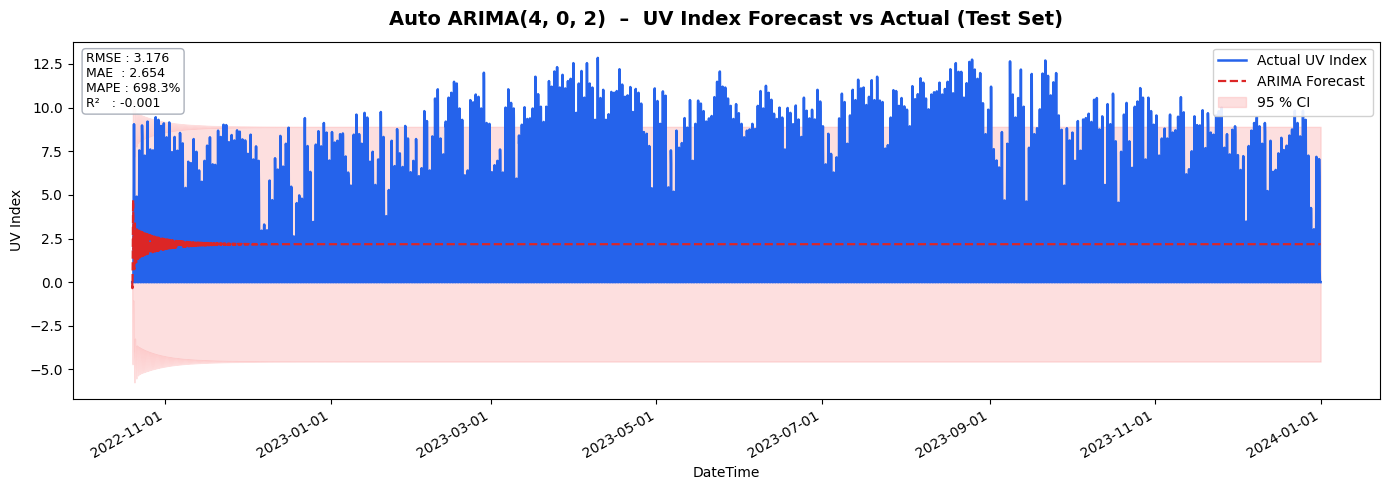

Saved → arima_test_forecast.png


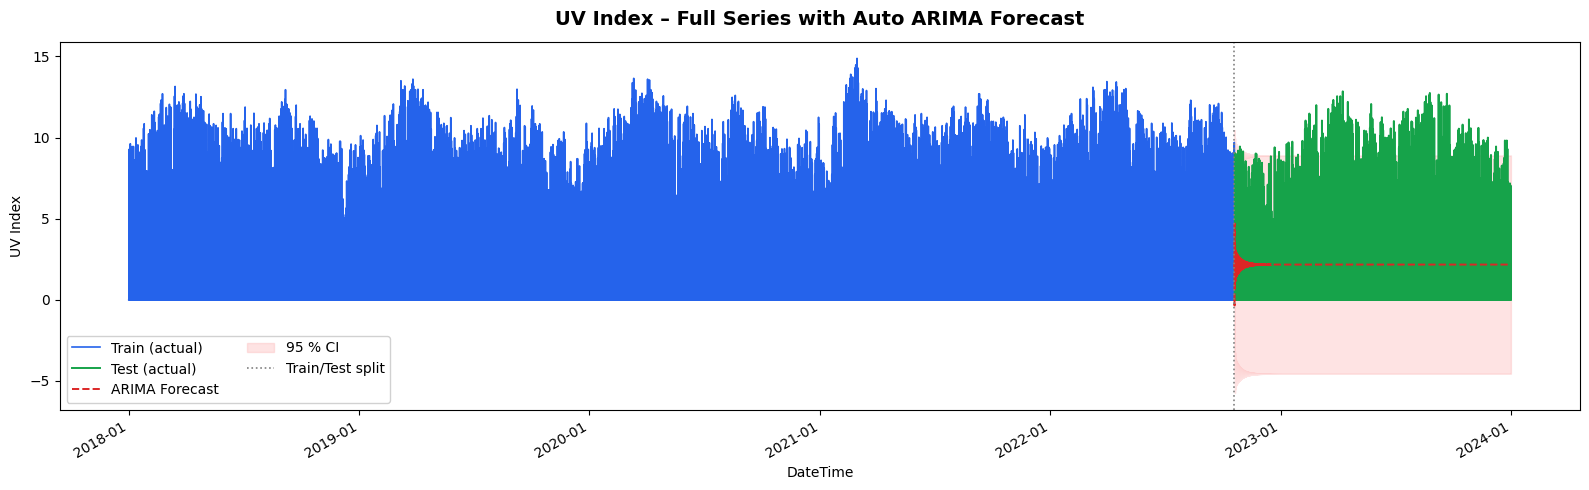

Saved → arima_full_series.png


In [2]:
"""
Auto ARIMA – UV_INDEX Forecasting
==================================
• 80 / 20 train-test split (temporal order preserved)
• Metrics : RMSE, MSE, MAE, MAPE, R²
• Plots   : Actual vs Predicted (test set) + full series overview
"""

# ── 0. Installs (run once) ────────────────────────────────────────────────────
# pip install pmdarima statsmodels matplotlib pandas numpy scikit-learn

import warnings, subprocess, sys
warnings.filterwarnings('ignore')
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pmdarima', 'statsmodels', '--quiet'], check=False)

# ── 1. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pmdarima import auto_arima
from tabulate import tabulate          # optional – pip install tabulate

# ── 2. Reproduce the preprocessed DataFrame ───────────────────────────────────
#   (paste your earlier preprocessing block here, or just load original_df)
#   We assume `original_df` is already in memory from your preprocessing code.
#   If running this file standalone, load a saved copy:
#
#   original_df = pd.read_csv('original_df.csv', index_col='DateTime',
#                              parse_dates=True)
# Backup
import pandas as pd

# Google Sheet ID
sheet_id = "1tkwNAQthWNZhHbr_HBVzcAKdE1LV1Adc7-3W3Gl48a4"

# Convert to CSV export link
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

# Load data
df = pd.read_csv(csv_url)

# Backup
df_backup = df.copy()

df.head()
df_backup = df.copy()

df.head()
df['DateTime'] = pd.to_datetime(
    df[['YEAR','MO','DY','HR']].rename(
        columns={'YEAR':'year','MO':'month','DY':'day','HR':'hour'}
    )
)
df = df.set_index('DateTime').drop(columns=['YEAR','MO','DY','HR'])
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].replace(-999.0, np.nan)
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].interpolate(method='polynomial', order=3)
df = df.rename(columns={'ALLSKY_SFC_UV_INDEX': 'UV_INDEX'})

original_df=df.copy()
# ── 3. Extract UV_INDEX series ────────────────────────────────────────────────
series = original_df['UV_INDEX'].dropna()

# ── 4. 80 / 20 Train-Test Split ───────────────────────────────────────────────
split_idx = int(len(series) * 0.80)
train = series.iloc[:split_idx]
test  = series.iloc[split_idx:]

print(f"Total observations : {len(series)}")
print(f"Train size         : {len(train)}  ({train.index[0]} → {train.index[-1]})")
print(f"Test  size         : {len(test)}   ({test.index[0]} → {test.index[-1]})")

# ── 5. Fit Auto ARIMA ─────────────────────────────────────────────────────────
print("\nFitting Auto ARIMA … (this may take a few minutes)")

model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,                   # auto-detect differencing
    seasonal=False,           # set True + m=12 for monthly seasonality etc.
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    n_jobs=-1,
)

print(f"\nBest model : ARIMA{model.order}")
print(model.summary())

# ── 6. Forecast on Test Set ───────────────────────────────────────────────────
n_test    = len(test)
forecast, conf_int = model.predict(n_periods=n_test, return_conf_int=True)

forecast_series = pd.Series(forecast, index=test.index)
lower           = pd.Series(conf_int[:, 0], index=test.index)
upper           = pd.Series(conf_int[:, 1], index=test.index)

# ── 7. Metrics ────────────────────────────────────────────────────────────────
actual = test.values
pred   = forecast_series.values

mse  = mean_squared_error(actual, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(actual, pred)
r2   = r2_score(actual, pred)

# MAPE (guard against zero actuals)
nonzero = actual != 0
mape = np.mean(np.abs((actual[nonzero] - pred[nonzero]) / actual[nonzero])) * 100

metrics = [
    ["MSE",    f"{mse:.4f}"],
    ["RMSE",   f"{rmse:.4f}"],
    ["MAE",    f"{mae:.4f}"],
    ["MAPE",   f"{mape:.2f} %"],
    ["R²",     f"{r2:.4f}"],
]

print("\n── Test-Set Metrics ─────────────────────────")
try:
    print(tabulate(metrics, headers=["Metric", "Value"], tablefmt="rounded_outline"))
except Exception:
    for m in metrics:
        print(f"  {m[0]:<6}: {m[1]}")

# ── 8. Plot 1 – Actual vs Predicted (Test Set) ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, actual,           color='#2563EB', lw=1.8,
        label='Actual UV Index')
ax.plot(test.index, pred,             color='#DC2626', lw=1.6,
        linestyle='--', label='ARIMA Forecast')
ax.fill_between(test.index, lower, upper,
                color='#FCA5A5', alpha=0.35, label='95 % CI')

ax.set_title(f'Auto ARIMA{model.order}  –  UV Index Forecast vs Actual (Test Set)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('DateTime')
ax.set_ylabel('UV Index')
ax.legend(framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

# Annotate metrics box
textstr = '\n'.join([f"RMSE : {rmse:.3f}",
                     f"MAE  : {mae:.3f}",
                     f"MAPE : {mape:.1f}%",
                     f"R²   : {r2:.3f}"])
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#9CA3AF')
ax.text(0.01, 0.97, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('arima_test_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → arima_test_forecast.png")

# ── 9. Plot 2 – Full Series + Forecast ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16, 5))

ax2.plot(train.index, train.values, color='#2563EB', lw=1.2,
         label='Train (actual)')
ax2.plot(test.index,  actual,       color='#16A34A', lw=1.4,
         label='Test (actual)')
ax2.plot(test.index,  pred,         color='#DC2626', lw=1.4,
         linestyle='--', label='ARIMA Forecast')
ax2.fill_between(test.index, lower, upper,
                 color='#FCA5A5', alpha=0.30, label='95 % CI')

ax2.axvline(x=test.index[0], color='gray', linestyle=':', lw=1.2,
            label='Train/Test split')
ax2.set_title('UV Index – Full Series with Auto ARIMA Forecast',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('DateTime')
ax2.set_ylabel('UV Index')
ax2.legend(framealpha=0.9, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig2.autofmt_xdate()

plt.tight_layout()
plt.savefig('arima_full_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → arima_full_series.png")

# Jaffna

Total observations : 52584
Train size         : 42067  (2018-01-01 00:00:00 → 2022-10-19 18:00:00)
Test  size         : 10517   (2022-10-19 19:00:00 → 2023-12-31 23:00:00)

Fitting Auto ARIMA … (this may take a few minutes)

Best model : ARIMA(4, 0, 5)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                42067
Model:               SARIMAX(4, 0, 5)   Log Likelihood              -38503.256
Date:                Sat, 04 Apr 2026   AIC                          77028.511
Time:                        02:30:45   BIC                          77123.628
Sample:                    01-01-2018   HQIC                         77058.547
                         - 10-19-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

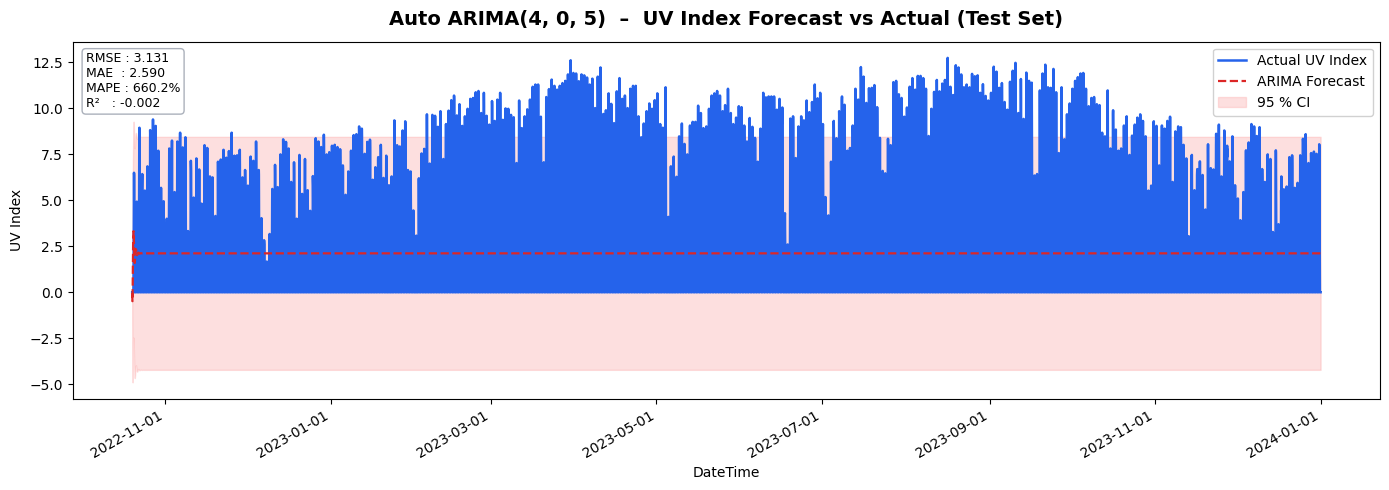

Saved → arima_test_forecast.png


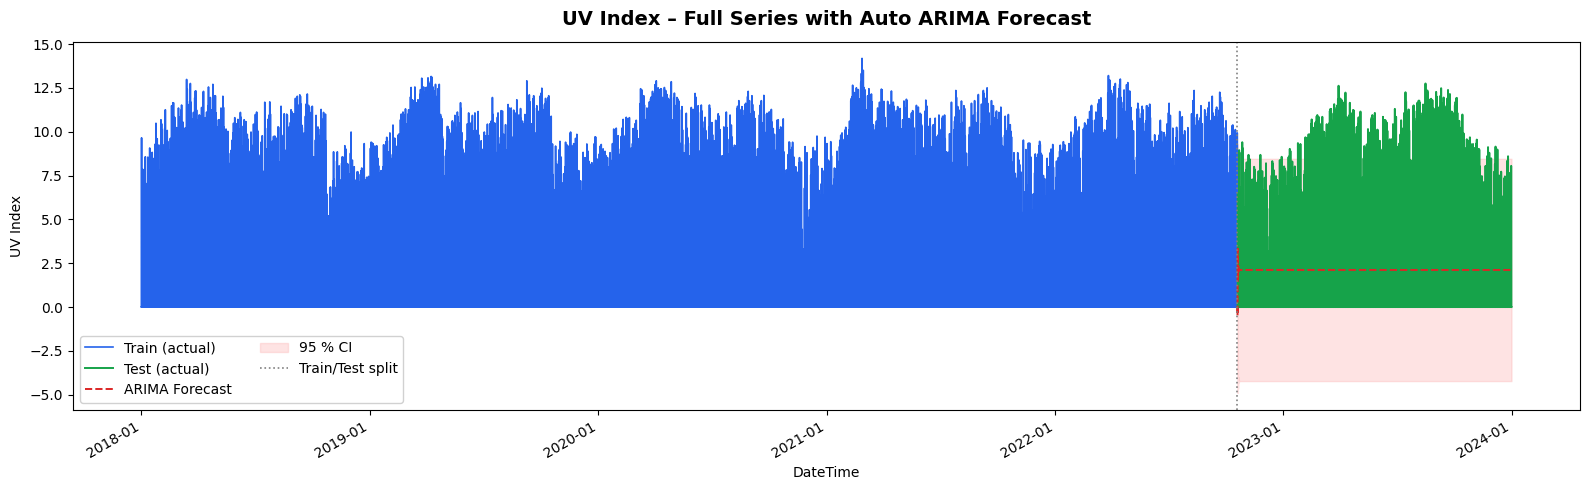

Saved → arima_full_series.png


In [3]:
"""
Auto ARIMA – UV_INDEX Forecasting
==================================
• 80 / 20 train-test split (temporal order preserved)
• Metrics : RMSE, MSE, MAE, MAPE, R²
• Plots   : Actual vs Predicted (test set) + full series overview
"""

# ── 0. Installs (run once) ────────────────────────────────────────────────────
# pip install pmdarima statsmodels matplotlib pandas numpy scikit-learn

import warnings, subprocess, sys
warnings.filterwarnings('ignore')
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pmdarima', 'statsmodels', '--quiet'], check=False)

# ── 1. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pmdarima import auto_arima
from tabulate import tabulate          # optional – pip install tabulate

# ── 2. Reproduce the preprocessed DataFrame ───────────────────────────────────
#   (paste your earlier preprocessing block here, or just load original_df)
#   We assume `original_df` is already in memory from your preprocessing code.
#   If running this file standalone, load a saved copy:
#
#   original_df = pd.read_csv('original_df.csv', index_col='DateTime',
#                              parse_dates=True)
import pandas as pd

# Google Drive File ID (from your new link)
file_id = "1El7t3dWhDydV8JNbRqxrx3RfVKHNw4IF"

# Direct download link
download_url = f"https://drive.google.com/uc?id={file_id}"

# Load data (assumes it's a CSV file)
df = pd.read_csv(download_url)

# Backup
df_backup = df.copy()

df.head()
df['DateTime'] = pd.to_datetime(
    df[['YEAR','MO','DY','HR']].rename(
        columns={'YEAR':'year','MO':'month','DY':'day','HR':'hour'}
    )
)
df = df.set_index('DateTime').drop(columns=['YEAR','MO','DY','HR'])
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].replace(-999.0, np.nan)
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].interpolate(method='polynomial', order=3)
df = df.rename(columns={'ALLSKY_SFC_UV_INDEX': 'UV_INDEX'})

original_df=df.copy()
# ── 3. Extract UV_INDEX series ────────────────────────────────────────────────
series = original_df['UV_INDEX'].dropna()

# ── 4. 80 / 20 Train-Test Split ───────────────────────────────────────────────
split_idx = int(len(series) * 0.80)
train = series.iloc[:split_idx]
test  = series.iloc[split_idx:]

print(f"Total observations : {len(series)}")
print(f"Train size         : {len(train)}  ({train.index[0]} → {train.index[-1]})")
print(f"Test  size         : {len(test)}   ({test.index[0]} → {test.index[-1]})")

# ── 5. Fit Auto ARIMA ─────────────────────────────────────────────────────────
print("\nFitting Auto ARIMA … (this may take a few minutes)")

model = auto_arima(
    train,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,                   # auto-detect differencing
    seasonal=False,           # set True + m=12 for monthly seasonality etc.
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    n_jobs=-1,
)

print(f"\nBest model : ARIMA{model.order}")
print(model.summary())

# ── 6. Forecast on Test Set ───────────────────────────────────────────────────
n_test    = len(test)
forecast, conf_int = model.predict(n_periods=n_test, return_conf_int=True)

forecast_series = pd.Series(forecast, index=test.index)
lower           = pd.Series(conf_int[:, 0], index=test.index)
upper           = pd.Series(conf_int[:, 1], index=test.index)

# ── 7. Metrics ────────────────────────────────────────────────────────────────
actual = test.values
pred   = forecast_series.values

mse  = mean_squared_error(actual, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(actual, pred)
r2   = r2_score(actual, pred)

# MAPE (guard against zero actuals)
nonzero = actual != 0
mape = np.mean(np.abs((actual[nonzero] - pred[nonzero]) / actual[nonzero])) * 100

metrics = [
    ["MSE",    f"{mse:.4f}"],
    ["RMSE",   f"{rmse:.4f}"],
    ["MAE",    f"{mae:.4f}"],
    ["MAPE",   f"{mape:.2f} %"],
    ["R²",     f"{r2:.4f}"],
]

print("\n── Test-Set Metrics ─────────────────────────")
try:
    print(tabulate(metrics, headers=["Metric", "Value"], tablefmt="rounded_outline"))
except Exception:
    for m in metrics:
        print(f"  {m[0]:<6}: {m[1]}")

# ── 8. Plot 1 – Actual vs Predicted (Test Set) ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, actual,           color='#2563EB', lw=1.8,
        label='Actual UV Index')
ax.plot(test.index, pred,             color='#DC2626', lw=1.6,
        linestyle='--', label='ARIMA Forecast')
ax.fill_between(test.index, lower, upper,
                color='#FCA5A5', alpha=0.35, label='95 % CI')

ax.set_title(f'Auto ARIMA{model.order}  –  UV Index Forecast vs Actual (Test Set)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('DateTime')
ax.set_ylabel('UV Index')
ax.legend(framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

# Annotate metrics box
textstr = '\n'.join([f"RMSE : {rmse:.3f}",
                     f"MAE  : {mae:.3f}",
                     f"MAPE : {mape:.1f}%",
                     f"R²   : {r2:.3f}"])
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#9CA3AF')
ax.text(0.01, 0.97, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('arima_test_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → arima_test_forecast.png")

# ── 9. Plot 2 – Full Series + Forecast ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16, 5))

ax2.plot(train.index, train.values, color='#2563EB', lw=1.2,
         label='Train (actual)')
ax2.plot(test.index,  actual,       color='#16A34A', lw=1.4,
         label='Test (actual)')
ax2.plot(test.index,  pred,         color='#DC2626', lw=1.4,
         linestyle='--', label='ARIMA Forecast')
ax2.fill_between(test.index, lower, upper,
                 color='#FCA5A5', alpha=0.30, label='95 % CI')

ax2.axvline(x=test.index[0], color='gray', linestyle=':', lw=1.2,
            label='Train/Test split')
ax2.set_title('UV Index – Full Series with Auto ARIMA Forecast',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('DateTime')
ax2.set_ylabel('UV Index')
ax2.legend(framealpha=0.9, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig2.autofmt_xdate()

plt.tight_layout()
plt.savefig('arima_full_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → arima_full_series.png")